# Independent Component Analysis (ICA) - Cocktail Party

**Objectif**: separer des signaux sources melanges (probleme de cocktail party) avec `FastICA`, en faisant une selection d'hyperparametres sur un jeu de validation explicite.

- Source des donnees: Kaggle (Cocktail Party dataset)
- Approche: split temporel train/val/test -> selection de `n_components` et `fun` via validation -> evaluation test
- Metriques: reconstruction MSE + score d'independance (kurtosis moyenne absolue)

In [4]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.stats import kurtosis

try:
    import librosa
except Exception:
    librosa = None

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
from sklearn.metrics import mean_squared_error

In [5]:
# 1) Chargement des donnees Cocktail Party (chemins directs, sans recherche)
data_dir = Path("Cocktail_Party")
if not data_dir.exists():
    raise RuntimeError("Dossier introuvable: './Cocktail_Party'.")

mix_path = data_dir / "Audio mix.mp3"
ref_paths = [
    data_dir / "Chicago - British Woman.mp3",
    data_dir / "Miami - Australian Woman.mp3",
    data_dir / "New York - American Man.mp3",
    data_dir / "Washinton - American Woman.mp3",
]

required_files = [mix_path] + ref_paths
missing_files = [p for p in required_files if not p.exists()]
if len(missing_files) > 0:
    raise RuntimeError(
        "Fichiers manquants dans './Cocktail_Party':\n" + "\n".join(str(p) for p in missing_files)
    )

# Conserve la meme variable pour les cellules suivantes
audio_files = required_files

if mix_path.suffix.lower() == ".wav":
    sr, mix_signal = wavfile.read(mix_path)
    mix_signal = np.asarray(mix_signal, dtype=np.float64)
else:
    if librosa is None:
        raise RuntimeError("Fichier MP3 detecte mais librosa n'est pas installe. Installe-le via: pip install librosa")
    mix_signal, sr = librosa.load(mix_path, sr=None, mono=False)
    mix_signal = np.asarray(mix_signal, dtype=np.float64)
    if mix_signal.ndim == 2:
        mix_signal = mix_signal.T

# Normalisation de base pour stabiliser FastICA
if np.max(np.abs(mix_signal)) > 0:
    mix_signal = mix_signal / np.max(np.abs(mix_signal))

print(f"Dossier dataset utilise: {data_dir.resolve()}")
print(f"Mix file utilise: {mix_path}")
print(f"Sample rate: {sr} Hz | Shape brut: {mix_signal.shape}")

Dossier dataset utilise: D:\100DaysofML\Notebooks\074_ICA\Cocktail_Party
Mix file utilise: Cocktail_Party\Audio mix.mp3
Sample rate: 24000 Hz | Shape brut: (1842574, 2)


In [3]:
# 2) Construction de la matrice d'observations + split train/val/test
# On utilise des embeddings temporels pour augmenter le nombre d'observations ICA.
if mix_signal.ndim == 1:
    mix_2d = mix_signal.reshape(-1, 1)
else:
    mix_2d = mix_signal

n_samples, n_channels = mix_2d.shape
embed_lag = 7      # fenetre temporelle = 8
frame_hop = 2      # sous-echantillonnage pour accelerer

if n_samples <= embed_lag + 1:
    raise RuntimeError("Signal trop court pour l'embedding temporel.")

X_full = np.hstack([
    mix_2d[i:n_samples - embed_lag + i, :]
    for i in range(embed_lag + 1)
])

X = X_full[::frame_hop]

print(f"Signal original: {mix_2d.shape}")
print(f"X apres embedding: {X.shape} (channels={n_channels}, lag={embed_lag}, hop={frame_hop})")

# Split temporel explicite (pas de shuffle) pour garder la coherence signal
X_train_full, X_test = train_test_split(X, test_size=0.2, shuffle=False)
X_train, X_val = train_test_split(X_train_full, test_size=0.25, shuffle=False)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

Signal original: (1842574, 2)
X apres embedding: (921284, 16) (channels=2, lag=7, hop=2)
Train: (552770, 16), Val: (184257, 16), Test: (184257, 16)


In [4]:
# 3) Selection d'hyperparametres via validation
max_comp = min(8, X_train_s.shape[1])
n_components_grid = list(range(2, max_comp + 1))

if len(n_components_grid) == 0:
    raise RuntimeError("Grille n_components vide. Verifie la construction de X.")

fun_grid = ["logcosh", "exp", "cube"]
results = []

for n_comp in n_components_grid:
    for fun in fun_grid:
        try:
            ica = FastICA(
                n_components=n_comp,
                fun=fun,
                random_state=42,
                max_iter=2000,
                tol=1e-4,
            )

            S_train = ica.fit_transform(X_train_s)
            S_val = ica.transform(X_val_s)
            X_val_rec = ica.inverse_transform(S_val)

            val_mse = mean_squared_error(X_val_s, X_val_rec)
            indep_score = float(np.mean(np.abs(kurtosis(S_train, axis=0, fisher=True))))

            # Poids leger sur la reconstruction pour garder le focus separation.
            score = indep_score - 0.1 * val_mse

            results.append(
                {
                    "n_components": n_comp,
                    "fun": fun,
                    "val_reconstruction_mse": val_mse,
                    "independence_score": indep_score,
                    "selection_score": score,
                    "n_iter": int(getattr(ica, "n_iter_", -1)),
                }
            )
        except Exception:
            continue

if len(results) == 0:
    raise RuntimeError("Aucun modele ICA valide pendant la phase de selection.")

results_df = pd.DataFrame(results).sort_values("selection_score", ascending=False).reset_index(drop=True)
display(results_df.head(12))

best_n = int(results_df.loc[0, "n_components"])
best_fun = str(results_df.loc[0, "fun"])
best_sel = float(results_df.loc[0, "selection_score"])

print(f"Meilleur n_components (validation): {best_n}")
print(f"Meilleure fonction non-lineaire: {best_fun}")
print(f"Selection score max: {best_sel:.4f}")

,n_components,fun,val_reconstruction_mse,independence_score,selection_score,n_iter
0,8,cube,4.391184e-30,15.681305,15.681305,30
1,8,logcosh,4.334777e-30,14.857906,14.857906,21
2,8,exp,3.292282e-30,14.745589,14.745589,24
3,7,cube,1.103677e-03,14.162185,14.162075,28
4,7,logcosh,1.103677e-03,14.079018,14.078907,27
5,7,exp,1.103677e-03,14.011508,14.011398,24
6,6,cube,8.169653e-03,12.411659,12.410842,27
7,5,cube,1.941236e-02,12.367839,12.365898,4
8,5,logcosh,1.941236e-02,12.343468,12.341527,6
9,5,exp,1.941236e-02,12.330768,12.328827,7


Meilleur n_components (validation): 8
Meilleure fonction non-lineaire: cube
Selection score max: 15.6813


In [5]:
# 4) Refit sur train+val avec les meilleurs hyperparametres, puis evaluation test
X_trainval = np.vstack([X_train, X_val])
scaler_final = StandardScaler()
X_trainval_s = scaler_final.fit_transform(X_trainval)
X_test_s_final = scaler_final.transform(X_test)

best_ica = FastICA(
    n_components=best_n,
    fun=best_fun,
    random_state=42,
    max_iter=2000,
    tol=1e-4,
)

S_trainval = best_ica.fit_transform(X_trainval_s)
S_test = best_ica.transform(X_test_s_final)
X_test_rec = best_ica.inverse_transform(S_test)

test_mse = mean_squared_error(X_test_s_final, X_test_rec)
test_indep = float(np.mean(np.abs(kurtosis(S_test, axis=0, fisher=True))))

print(f'Test reconstruction MSE: {test_mse:.6f}')
print(f'Test independence score (|kurtosis| moyen): {test_indep:.6f}')
print(f'Forme des composantes separees sur test: {S_test.shape}')

Test reconstruction MSE: 0.000000
Test independence score (|kurtosis| moyen): 21.128451
Forme des composantes separees sur test: (184257, 8)


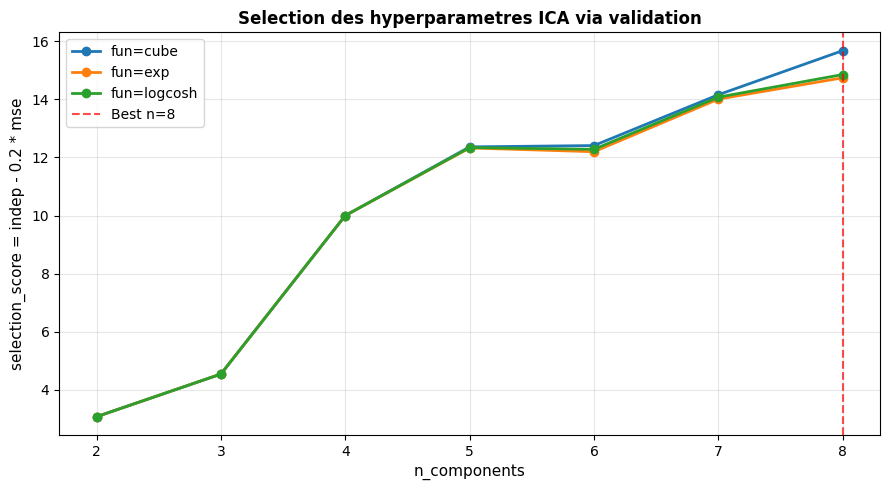

In [6]:
# 5) Visualisation: score de selection selon n_components
pivot = results_df.pivot_table(index='n_components', columns='fun', values='selection_score', aggfunc='mean')

plt.figure(figsize=(9, 5))
for fun in pivot.columns:
    plt.plot(pivot.index, pivot[fun], marker='o', linewidth=2, label=f'fun={fun}')

plt.axvline(best_n, color='red', linestyle='--', alpha=0.7, label=f'Best n={best_n}')
plt.title('Selection des hyperparametres ICA via validation', fontsize=12, fontweight='bold')
plt.xlabel('n_components', fontsize=11)
plt.ylabel('selection_score = indep - 0.2 * mse', fontsize=11)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

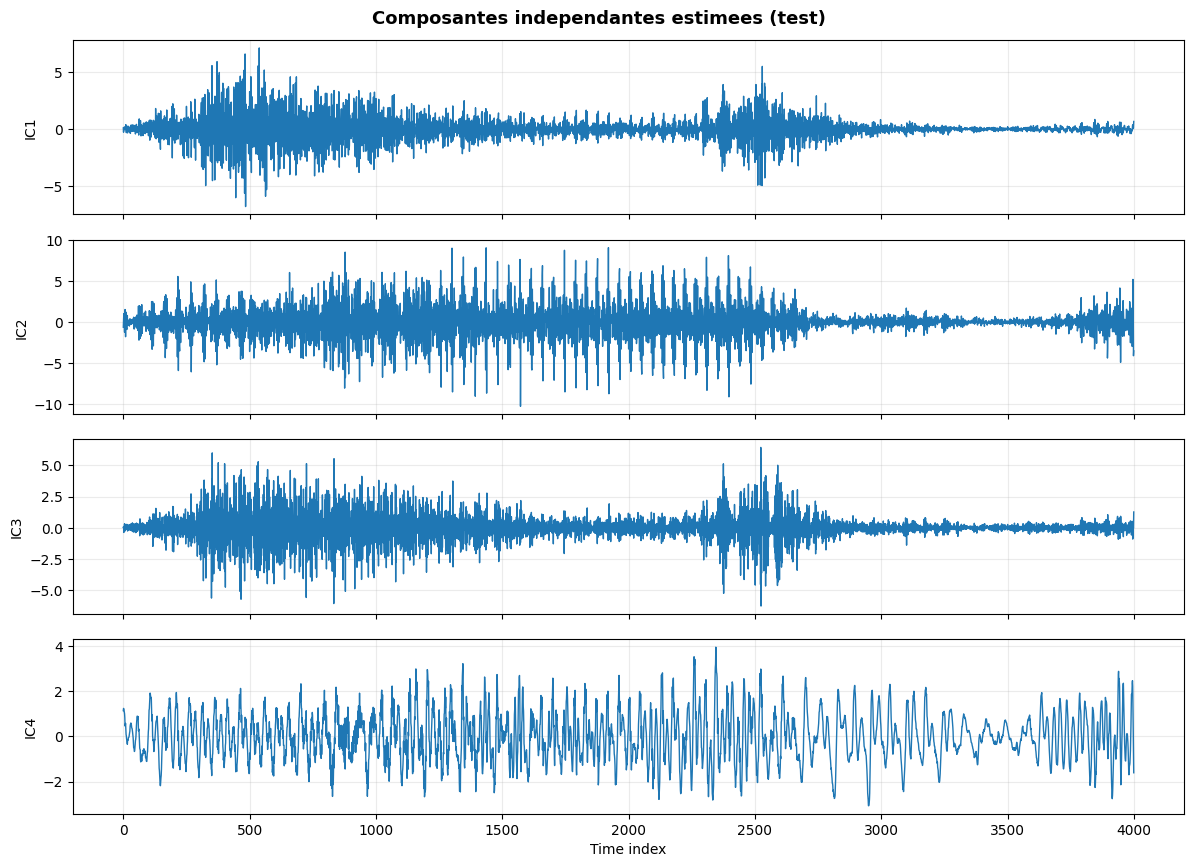

In [7]:
# 6) Visualisation des composantes separees (fenetre temporelle)
n_plot = min(4000, S_test.shape[0])
n_show = min(best_n, 4)

fig, axes = plt.subplots(n_show, 1, figsize=(12, 2.2 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    axes[i].plot(S_test[:n_plot, i], linewidth=1.0)
    axes[i].set_ylabel(f'IC{i+1}')
    axes[i].grid(alpha=0.25)

axes[-1].set_xlabel('Time index')
fig.suptitle('Composantes independantes estimees (test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# 7) Metriques rapides avec reference: SI-SDR (4 voix)
from itertools import permutations
from sklearn.metrics import mean_squared_error

# Metriques deja disponibles et rapides
mse_test = float(mean_squared_error(X_test_s_final, X_test_rec))
best_n_val = int(best_n)
corr = np.corrcoef(S_test, rowvar=False)
off_diag_mask = ~np.eye(corr.shape[0], dtype=bool)
avg_abs_corr = float(np.mean(np.abs(corr[off_diag_mask])))

# Charger les 4 voix de reference (fichiers hors mix)
ref_paths = [
    p for p in audio_files
    if p != mix_path and not any(k in p.name.lower() for k in ['mix', 'mixture', 'mixed'])
]
ref_paths = ref_paths[:4]

def _load_mono(path_obj, target_sr):
    if path_obj.suffix.lower() == '.wav':
        _sr, arr = wavfile.read(path_obj)
        arr = np.asarray(arr, dtype=np.float64)
        if arr.ndim == 2:
            arr = arr.mean(axis=1)
        if _sr != target_sr and librosa is not None:
            arr = librosa.resample(arr, orig_sr=_sr, target_sr=target_sr)
        return arr
    if librosa is None:
        raise RuntimeError('Librosa est requis pour lire les fichiers MP3 de reference.')
    arr, _ = librosa.load(path_obj, sr=target_sr, mono=True)
    return np.asarray(arr, dtype=np.float64)

def _si_sdr_db(ref_sig, est_sig, eps=1e-10):
    ref_sig = ref_sig - np.mean(ref_sig)
    est_sig = est_sig - np.mean(est_sig)
    alpha = np.dot(est_sig, ref_sig) / (np.dot(ref_sig, ref_sig) + eps)
    target = alpha * ref_sig
    noise = est_sig - target
    return 10.0 * np.log10((np.sum(target * target) + eps) / (np.sum(noise * noise) + eps))

si_sdr_mean = np.nan
if len(ref_paths) >= 2:
    # Conserver les composantes ICA les plus energetiques
    n_ref = min(4, len(ref_paths))
    comp_idx = np.argsort(np.var(S_test, axis=0))[::-1][:n_ref]
    S_eval = S_test[:, comp_idx]

    # Aligner temporellement les references sur la grille de S_test
    ref_eval = []
    base_len = n_samples - embed_lag
    for p in ref_paths[:n_ref]:
        src = _load_mono(p, sr)
        if src.shape[0] < base_len:
            src = np.pad(src, (0, base_len - src.shape[0]))
        src = src[:base_len]
        src = src[::frame_hop]
        src_test = src[-S_eval.shape[0]:]
        ref_eval.append(src_test)

    ref_eval = np.column_stack(ref_eval)

    # Matrice SI-SDR (refs x composantes) + meilleur appariement
    si_mat = np.zeros((n_ref, n_ref), dtype=float)
    for i in range(n_ref):
        for j in range(n_ref):
            si_mat[i, j] = _si_sdr_db(ref_eval[:, i], S_eval[:, j])

    best_score = -np.inf
    for perm in permutations(range(n_ref)):
        score = float(np.mean([si_mat[i, perm[i]] for i in range(n_ref)]))
        if score > best_score:
            best_score = score
    si_sdr_mean = best_score

mini_metrics_df = pd.DataFrame(
    {
        'metric': [
            'Best n_components (validation)',
            'MSE reconstruction (test)',
            'Avg |corr| between components (test)',
            'Mean SI-SDR (dB) vs 4 reference voices',
        ],
        'value': [
            best_n_val,
            round(mse_test, 6),
            round(avg_abs_corr, 6),
            round(float(si_sdr_mean), 4) if np.isfinite(si_sdr_mean) else np.nan,
        ],
    }
)

display(mini_metrics_df)

,metric,value
0,Best n_components (validation),8.000000
1,MSE reconstruction (test),0.000000
2,Avg |corr| between components (test),0.014256
3,Mean SI-SDR (dB) vs 4 reference voices,-20.131300
